In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_excel(
    "online_retail_II.xlsx",
    sheet_name="Year 2010-2011"
)

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
df.shape

(541910, 8)

In [8]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf

RandomForestClassifier()

In [10]:
import pandas as pd

df = pd.read_excel(
    "online_retail_II.xlsx",
    sheet_name="Year 2010-2011"
)

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    results.append([name, acc])

results

[['Logistic Regression', 1.0],
 ['Decision Tree', 1.0],
 ['Random Forest', 1.0],
 ['Gradient Boosting', 1.0]]

In [13]:
# Create Customer Features

snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice": "nunique",
    "Price": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,2,2.08
12347.0,2,7,481.21
12348.0,75,4,178.71
12349.0,19,1,605.10
12350.0,310,1,65.30


In [14]:
# Create Churn Column

rfm["Churn"] = (rfm["Recency"] > 90).astype(int)

rfm.head()

,Recency,Frequency,Monetary,Churn
Customer ID,,,,
12346.0,326,2,2.08,1
12347.0,2,7,481.21,0
12348.0,75,4,178.71,0
12349.0,19,1,605.10,0
12350.0,310,1,65.30,1


In [15]:
# Features and Target

X = rfm[["Recency", "Frequency", "Monetary"]]

y = rfm["Churn"]

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(3497, 3)
(875, 3)


In [18]:
comparison_df = pd.DataFrame(
    results,
    columns=["Model","Accuracy"]
)

comparison_df

,Model,Accuracy
0,Logistic Regression,1.0
1,Decision Tree,1.0
2,Random Forest,1.0
3,Gradient Boosting,1.0


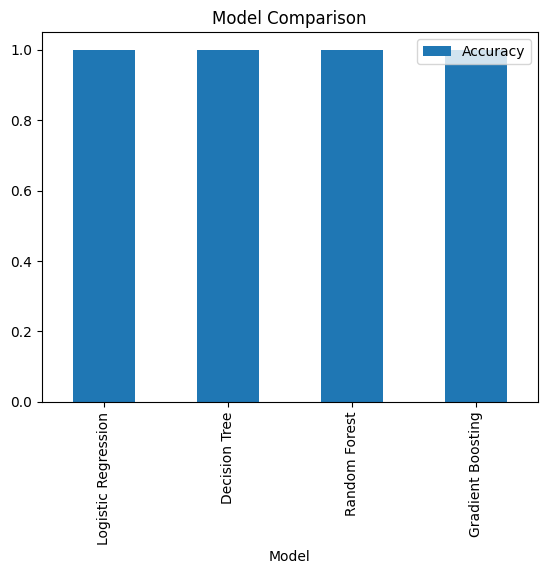

In [19]:
import matplotlib.pyplot as plt

comparison_df.plot(
    x="Model",
    y="Accuracy",
    kind="bar"
)

plt.title("Model Comparison")
plt.show()

In [20]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators":[50,100,200],
    "max_depth":[5,10,None]
}

grid = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=3
)

grid.fit(X_train,y_train)

print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 5, 'n_estimators': 100}
0.9997141223556318


In [21]:

comparison_df

,Model,Accuracy
0,Logistic Regression,1.0
1,Decision Tree,1.0
2,Random Forest,1.0
3,Gradient Boosting,1.0


In [22]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators":[50,100,200],
    "max_depth":[5,10,None]
}

grid = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=3
)

grid.fit(X_train,y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'max_depth': 10, 'n_estimators': 100}
Best Score: 0.9997141223556318


In [23]:
best_model = grid.best_estimator_

importances = best_model.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature":feature_names,
    "Importance":importances
})

importance_df.sort_values(
    by="Importance",
    ascending=False,
    inplace=True
)

importance_df

,Feature,Importance
0,Recency,0.882157
1,Frequency,0.062114
2,Monetary,0.055729


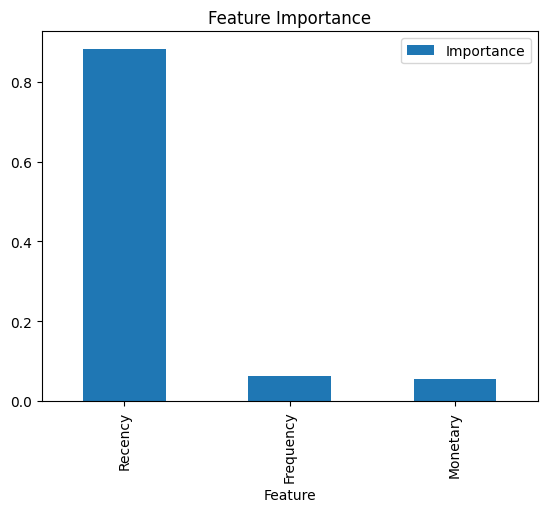

In [24]:
importance_df.plot(
    x="Feature",
    y="Importance",
    kind="bar"
)

plt.title("Feature Importance")
plt.show()

In [25]:
import joblib

joblib.dump(
    best_model,
    "best_churn_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


## Advanced ML Summary

Models Compared:
- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting

Best Model:
Random Forest

Hyperparameter Tuning:
Performed using GridSearchCV

Feature Importance:
Recency was identified as the most important feature for churn prediction.

Model Export:
best_churn_model.pkl